[[], []]

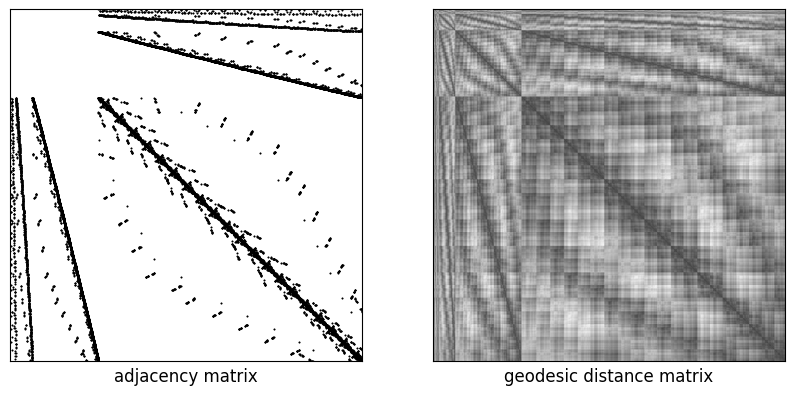

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from joblib import Parallel, delayed
from lapy import Solver, TriaMesh
from lapy.diffgeo import compute_geodesic_f
from neuromaps import nulls, stats
from nilearn import datasets, plotting
from sksparse.cholmod import cholesky

from compare_brain_maps import surface

# set notebook defaults
rng = np.random.default_rng(seed=0)
plt.rcParams["font.size"] = 12

# freesurfer pial left mesh
fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage4")
surface_mesh = surface.load_surf_mesh(fsaverage["pial_left"])
n_vertices = surface_mesh.coordinates.shape[0]


# lapy objects
mesh = TriaMesh(v=surface_mesh.coordinates, t=surface_mesh.faces)
fem = Solver(mesh, lump=True, use_cholmod=True)

# calculate adjacency matrix
A = surface.adjacency_matrix(surface_mesh)


# calculate geodesic distance matrix
@delayed
def geodesic_dist(vertex):
    """
    calculates geodesic distance from a source vertex using the heat method

    simulates heat diffusion from the vertex for a short time `t` and uses
    the resulting heat distribution gradient to estimate distances to all other vertices
    """
    t = mesh.avg_edge_length() ** 2
    backward_matrix = fem.mass + t * fem.stiffness
    factor = cholesky(backward_matrix)
    b0 = np.zeros(n_vertices)
    b0[vertex] = 1
    u = factor(b0)
    return compute_geodesic_f(mesh, u)


with Parallel(n_jobs=-2) as parallel:
    D = np.column_stack(parallel(geodesic_dist(vertex) for vertex in range(n_vertices)))
    idx = np.argsort(D, axis=1)
    D_sorted = np.sort(D, axis=1)
    clear_output()


# plot adjacency and geodesic distance matrices
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
axs[0].spy(A, ms=0.5, c="k")
axs[0].set_xlabel("adjacency matrix")
axs[1].imshow(D, cmap="binary_r", alpha=0.75)
axs[1].set_xlabel("geodesic distance matrix")
[ax.set_xticks([]) or ax.set_yticks([]) for ax in axs]

Solver: Cholesky decomposition from scikit-sparse cholmod ...


[<Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>]

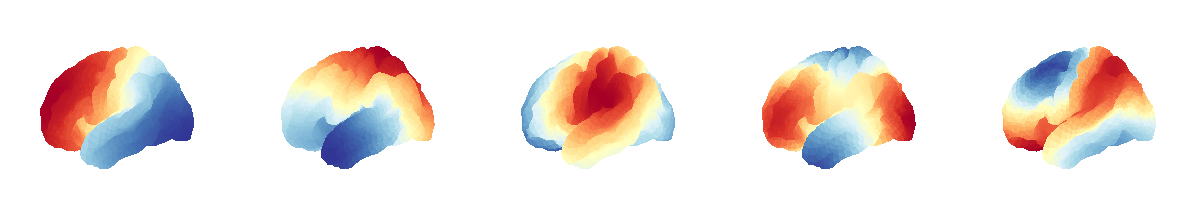

In [3]:
# laplace-beltrami eigenmodes
n_modes = 1000
evals, emodes = fem.eigs(k=n_modes + 1)
evals, emodes = evals[1:], emodes[:, 1:]  # first in non-constant

# plot first five eigenmodes
n_cols = 5
fig, axs = plt.subplots(ncols=n_cols, figsize=(15, 4), subplot_kw=dict(projection="3d"))
[plotting.plot_surf(surf_mesh=surface_mesh, surf_map=emodes[:, i], axes=axs[i], cmap="RdYlBu_r") for i in range(n_cols)]

heat kernel smoothing


[<Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>]

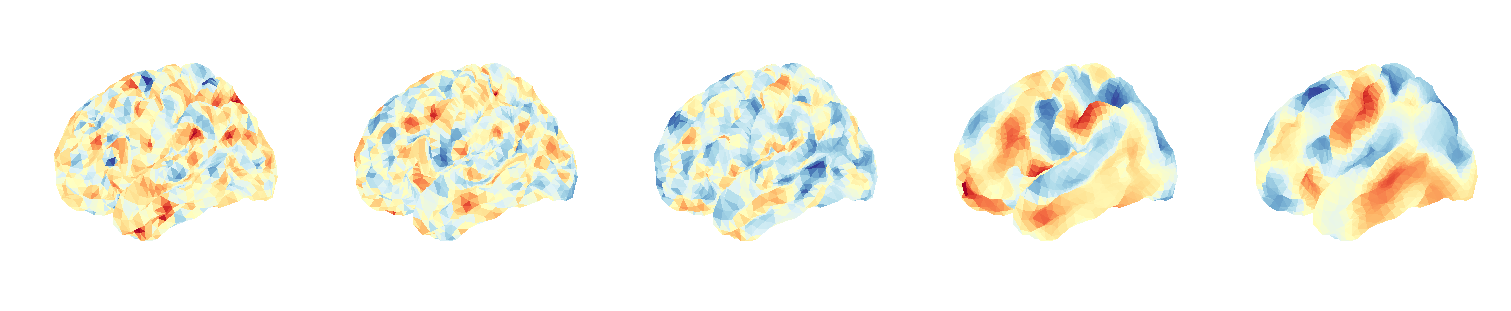

In [4]:
# heat kernel smoothing: generate five GRFs with increasing autocorrelation
def heat_kernel_smoothing(evals, emodes, sigma=1, seed=0):
    """heat kernel smoothing using LB eigenvalues, eigenmodes"""
    rng = np.random.default_rng(seed=seed)
    z = rng.standard_normal(size=len(evals))
    return np.sum(np.exp(-evals * sigma) * z * emodes, axis=1)


print("heat kernel smoothing")
sigmas = [0, 5, 10, 50, 100]
fig, axs = plt.subplots(ncols=n_cols, figsize=(15, 4), subplot_kw=dict(projection="3d"), layout="constrained")
[
    plotting.plot_surf(
        surf_mesh=surface_mesh,
        surf_map=heat_kernel_smoothing(evals, emodes, sigma=sigmas[i], seed=i),
        axes=axs[i],
        cmap="RdYlBu_r",
    )
    for i in range(n_cols)
]

iterative smoothing


[<Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>,
 <Figure size 1500x400 with 5 Axes>]

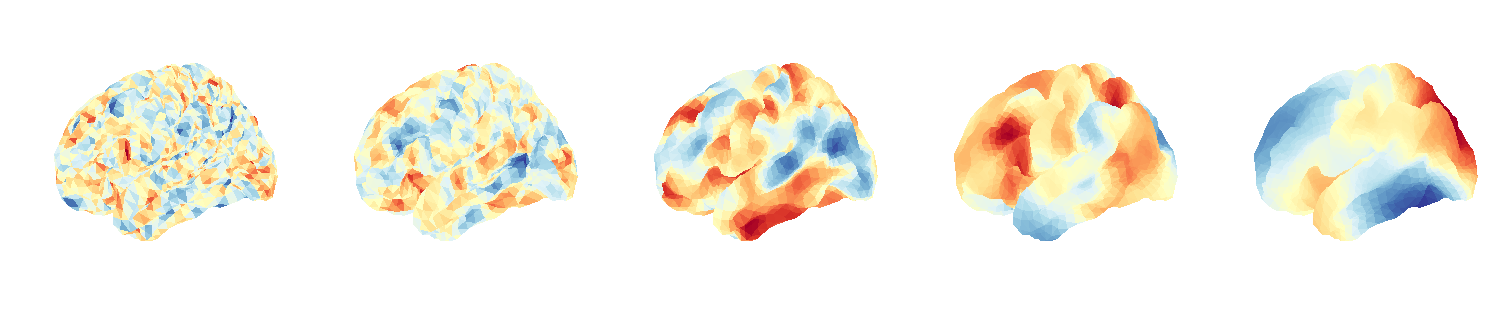

In [10]:
# iterative smoothing: generate five GRFs with increasing autocorrelation
print("iterative smoothing")
iterations = [0, 1, 5, 10, 40]
fig, axs = plt.subplots(ncols=n_cols, figsize=(15, 4), subplot_kw=dict(projection="3d"), layout="constrained")
[
    plotting.plot_surf(
        surf_mesh=surface_mesh,
        surf_map=surface.iterative_smoothing(
            surface_mesh, rng.standard_normal(size=n_vertices), n_iterations=int(iterations[i])
        ),
        axes=axs[i],
        cmap="RdYlBu_r",
    )
    for i in range(n_cols)
]

In [5]:
# simulation settings
alpha = 0.05
n_sets = 2
n_repeats = 1000
n_subsamples = 100
patch_sizes = np.asarray(iterations) + 4  # starts at ~ \sqrt{n_vertices}


# helper functions
def _xcorr(x1, x2):
    """estimate the correlation between two zero-centered maps"""
    return x1 @ x2 / (x1.std() * x2.std()) / x1.size


def _subsample_vertices(A, n_iterations=1, seed=0):
    """subsample a patch of adjacent vertices"""
    rng = np.random.default_rng(seed=seed)
    n_vertices = A.shape[0]
    patch = np.zeros(n_vertices)
    patch[rng.integers(0, n_vertices)] = 1
    for _ in range(n_iterations):
        patch = (A @ patch) > 0
    return patch


def _subsample_distribution(x1, x2, seed, patch_size):
    """compute the null distribution by subsampling"""
    xcorrs = np.zeros(n_subsamples)
    for subsample in range(n_subsamples):
        patch = _subsample_vertices(A, n_iterations=patch_size, seed=(seed + subsample))
        scale_std = np.sqrt(patch.sum() / n_vertices)
        xcorrs[subsample] = _xcorr(x1[patch], x2[patch]) * scale_std
    return xcorrs


def _spin_distribution(x1, x2, seed):
    """compute the null distribution by spins"""
    spins = nulls.alexander_bloch(None, atlas="fsaverage", density="3k", n_perm=n_subsamples, seed=seed)
    spins = spins[:n_vertices]  # select L hemisphere spins
    _, _, xcorrs = stats.compare_images(x1, x2, nulls=spins, return_nulls=True)
    return xcorrs


def _quantile_test(xcorr, xcorrs):
    """test if xcorr is outside the (alpha/2, 1-alpha/2) quantile interval"""
    lwr, upr = np.quantile(xcorrs, [alpha / 2, 1 - alpha / 2])
    return xcorr < lwr or xcorr > upr


# simulations, parallelize repeats
@delayed
def sim_iter(acorr, seed, patch_size):
    """iterative smoothing"""
    rng = np.random.default_rng(seed=seed)
    X = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_vertices)
    X_smooth = surface.smooth_surface_data(surface_mesh, X, iterations=acorr, match="dist")
    x1, x2 = X_smooth[:, 0], X_smooth[:, 1]
    x1 -= x1.mean()
    x2 -= x2.mean()
    xcorr = _xcorr(x1, x2)

    xcorrs_ss = _subsample_distribution(x1, x2, seed, patch_size)  # ss = subsample
    xcorrs_st = _spin_distribution(x1, x2, seed)  # st = spin test

    return (_quantile_test(xcorr, xcorrs_ss), _quantile_test(xcorr, xcorrs_st))


@delayed
def sim_heat(sigma, seed, patch_size):
    """heat kernel smoothing"""
    X_smooth = np.vstack([heat_kernel_smoothing(evals, emodes, sigma=sigma, seed=seed + i) for i in (0, 1)]).T
    x1, x2 = X_smooth[:, 0], X_smooth[:, 1]
    x1 -= x1.mean()
    x2 -= x2.mean()
    xcorr = _xcorr(x1, x2)

    xcorrs_ss = _subsample_distribution(x1, x2, seed, patch_size)  # ss = subsample
    xcorrs_st = _spin_distribution(x1, x2, seed)  # st = spin test

    return (_quantile_test(xcorr, xcorrs_ss), _quantile_test(xcorr, xcorrs_st))

In [ ]:
# !! 21 min runtime !!

fpr_iter = np.zeros((n_sets, len(iterations), 2))
fpr_heat = np.zeros((n_sets, len(sigmas), 2))

for i in range(n_sets):
    print(f"set {i + 1} of {n_sets}...")

    # iterative smoothing
    for j, (acorr, patch_size) in enumerate(zip(iterations, patch_sizes)):
        with Parallel(n_jobs=-2) as parallel:
            iter_results = parallel(
                sim_iter(acorr, (i * n_repeats + repeat), patch_size) for repeat in range(n_repeats)
            )
        fpr_iter[i, j, :] = np.mean(iter_results, axis=0)

    # heat kernel smoothing
    for j, (acorr, patch_size) in enumerate(zip(sigmas, patch_sizes)):
        with Parallel(n_jobs=-2) as parallel:
            heat_results = parallel(
                sim_heat(acorr, (i * n_repeats + repeat), patch_size) for repeat in range(n_repeats)
            )
        fpr_heat[i, j, :] = np.mean(heat_results, axis=0)

set 1 of 2...


/Users/griegner/git-repositories/compare-brain-maps/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


set 2 of 2...


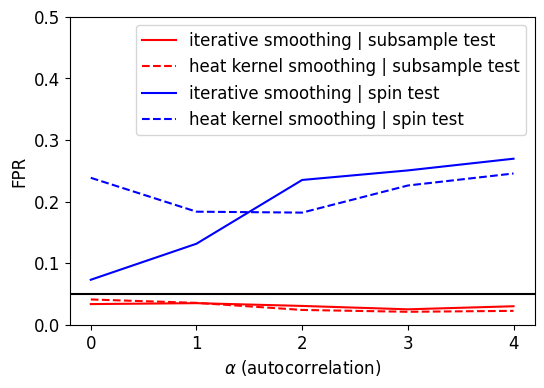

In [9]:
# plot simulations
fig, ax = plt.subplots(figsize=(6, 4))

mean_iter = fpr_iter.mean(axis=0)
mean_heat = fpr_heat.mean(axis=0)
xs = np.arange(5)

ax.axhline(y=alpha, color="k")
ax.plot(xs, mean_iter[:, 0], color="r", label="iterative smoothing | subsample test")
ax.plot(xs, mean_heat[:, 0], ls="--", color="r", label="heat kernel smoothing | subsample test")
ax.plot(xs, mean_iter[:, 1], color="b", label="iterative smoothing | spin test")
ax.plot(xs, mean_heat[:, 1], ls="--", color="b", label="heat kernel smoothing | spin test")
ax.set_ylim([0, 0.5])
ax.set_xticks(xs)
ax.set_ylabel("FPR")
ax.set_xlabel(r"$\alpha$ (autocorrelation)")
ax.legend()